In [2]:
DATASET_PATH = "../datasets/"

# M57-patent dataset

## Converting m57 desktop image xmls into csv

In [9]:
import xml.etree.ElementTree as ET
import pandas as pd
import os

def xml_to_raw_csv(xml_files, output_csv=f"{DATASET_PATH}/m57_raw_dump.csv"):
    all_rows = []
    
    for xml_file in xml_files:
        if not os.path.exists(xml_file):
            print(f"⚠️ Skipping missing file: {xml_file}")
            continue
            
        print(f"Parsing {xml_file}...")
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()
            
            source_user = os.path.basename(xml_file).split('-')[0]

            for file_obj in root.findall(".//fileobject"):
                # --- 1. OPTIMIZATION: Filter Directories Immediately ---
                ntype = file_obj.find("name_type")
                
                # 'd' = Directory. We skip these to save massive space.
                if ntype is not None and ntype.text == 'd':
                    continue

                row = {}
                row['source_user'] = source_user
                row['type'] = ntype.text if ntype is not None else "unknown"

                # --- 2. Extract Data ---
                
                # Filename (Raw)
                fname_tag = file_obj.find("filename")
                if fname_tag is not None:
                    row['raw_path'] = fname_tag.text
                else:
                    continue # Skip objects with no name

                # File Size
                fsize = file_obj.find("filesize")
                row['size'] = int(fsize.text) if fsize is not None else 0

                # Timestamps
                mtime = file_obj.find("mtime")
                row['mtime_iso'] = mtime.text if mtime is not None else None
                
                # Flags ('unalloc' = 1 means DELETED file)
                unalloc = file_obj.find("unalloc")
                row['is_deleted'] = 1 if (unalloc is not None and unalloc.text == '1') else 0

                all_rows.append(row)
                
        except Exception as e:
            print(f"❌ Error parsing {xml_file}: {e}")

    # Convert to DataFrame
    df = pd.DataFrame(all_rows)
    
    # Save raw output with BOM for VS Code compatibility
    df.to_csv(output_csv, index=False, encoding='utf-8-sig')
    print(f"\n✅ Success! Saved {len(df)} file rows (no directories) to '{output_csv}'")
    return df

# --- CONFIGURATION ---
target_files = [
    f"{DATASET_PATH}/charlie-2009-12-11.xml",
    f"{DATASET_PATH}/jo-2009-12-11-002.xml",
    f"{DATASET_PATH}/pat-2009-12-11.xml",
    f"{DATASET_PATH}/terry-2009-12-11-002.xml"
]

# RUN IT
xml_to_raw_csv(target_files)

⚠️ Skipping missing file: ../datasets//charlie-2009-12-11.xml
⚠️ Skipping missing file: ../datasets//jo-2009-12-11-002.xml
⚠️ Skipping missing file: ../datasets//pat-2009-12-11.xml
⚠️ Skipping missing file: ../datasets//terry-2009-12-11-002.xml

✅ Success! Saved 0 file rows (no directories) to '../datasets//m57_raw_dump.csv'


""


## Cleaning and modernizing m57 data

In [ ]:
import pandas as pd
import numpy as np
import datetime
import time
import random
import re

def clean_and_modernize(input_csv, output_csv):
    print(f"🚀 Starting Deep Modernization on {input_csv}...")
    df = pd.read_csv(input_csv)
    initial_len = len(df)

    # --- 1. HARSH FILTERING ---
    df = df[df["type"].isin(["r", "-"])]
    df = df[df["is_deleted"] == 0]
    df = df[~df["raw_path"].str.startswith("$")] # Remove NTFS metadata
    
    # Remove truly dead XP-era system noise that never appears in Win 11
    dead_xp_tech = ["pchealth", "helpctr", "i386", "MSN6"]
    df = df[~df["raw_path"].str.contains('|'.join(dead_xp_tech), case=False)]

    # --- 2. THE MODERNIZATION ENGINE ---
    TIME_SHIFT = 15 * 365 * 24 * 3600  # 2009 -> 2024
    current_unix = int(time.time())

    # Map for legacy -> modern pathing
    PATH_REPLACEMENTS = {
        r"Documents and Settings": r"Users",
        r"Local Settings\\Temporary Internet Files\\Content.IE5": r"AppData\\Local\\Microsoft\\Windows\\INetCache",
        r"Local Settings\\Application Data": r"AppData\\Local",
        r"Application Data": r"AppData\\Roaming",
        r"Local Settings": r"AppData\\Local",
        r"My Documents": r"Documents",
        r"Program Files\\OpenOffice.org 3": r"Program Files\\Microsoft Office\\root\\Office16",
        r"Python26": r"Python312",
        r"WINDOWS": r"Windows"
    }

    def process_row(row):
        raw_path = str(row["raw_path"])
        user = str(row["source_user"])
        
        # A. Base Windows formatting
        win_path = "C:\\" + raw_path.replace("/", "\\")

        # B. Regex-based legacy path migration
        for old, new in PATH_REPLACEMENTS.items():
            win_path = re.sub(old, new, win_path, flags=re.IGNORECASE)

        # C. Modern Enterprise Software Injection
        # We randomly turn some generic Program Files noise into modern apps
        if "Program Files" in win_path and random.random() < 0.15:
            modern_apps = ["Slack", "Microsoft Teams", "Zoom", "Discord", "Spotify", "CrowdStrike"]
            win_path = win_path.replace("Program Files", f"Program Files\\{random.choice(modern_apps)}")

        # D. Cloud & Workspace Context
        if "Users" in win_path:
            # Inject OneDrive for 20% of user files
            if "Documents" in win_path and random.random() < 0.20:
                win_path = win_path.replace("Documents", "OneDrive\\Documents")
            # Inject WSL (Windows Subsystem for Linux) paths
            elif random.random() < 0.05:
                win_path = win_path.replace("C:\\Users", r"\\wsl.localhost\Ubuntu\home")

        # Split directory and name
        if "\\" in win_path:
            path_dir, name = win_path.rsplit("\\", 1)
        else:
            path_dir, name = "C:\\", win_path

        # E. Modern Extension Upgrades
        if name.lower().endswith((".doc", ".xls", ".ppt")):
            if random.random() > 0.15: # 85% upgrade rate
                name += "x"

        # F. Advanced Timestamp Distribution
        try:
            if pd.notnull(row["mtime_iso"]):
                dt = datetime.datetime.fromisoformat(str(row["mtime_iso"]).replace("Z", "+00:00"))
                unix_time = int(dt.timestamp()) + TIME_SHIFT
            else:
                unix_time = current_unix - random.randint(0, 10**7)
        except:
            unix_time = current_unix
            
        # Ensure no dates in the future (Cap at today)
        unix_time = min(unix_time, current_unix)

        ext = "." + name.rsplit(".", 1)[-1].lower() if "." in name else ""

        return pd.Series([name, path_dir, ext, row["size"], unix_time, user])

    print("🛠️  Performing architectural re-mapping...")
    new_cols = ["filename", "path", "extension", "size_bytes", "mod_time_unix", "source_user"]
    df[new_cols] = df.apply(process_row, axis=1)

    # --- 3. INTELLIGENT DOWNSAMPLING ---
    # We want to keep unique artifacts but delete repetitive system bloat
    print("🧹 Cleaning up system bloat (Downsampling)...")
    
    # Heavy downsample for WinSxS and System32 (The "Big Noise")
    noise_patterns = ["winsxs", "system32", "syswow64", "driverstore", "inf"]
    noise_mask = df["path"].str.lower().str.contains('|'.join(noise_patterns))
    
    # Keep 5% of deep system noise, 100% of user/app noise
    df = df[~noise_mask | (np.random.rand(len(df)) < 0.05)]

    # --- 4. EXPORT ---
    df[new_cols].to_csv(output_csv, index=False)
    print(f"✅ Final Modernized Dataset: {output_csv} ({len(df)} rows)")

# Run it
clean_and_modernize(f"{DATASET_PATH}/m57_csvs/m57_raw_dump.csv", f"{DATASET_PATH}/m57_csvs/m57_modernized_paths.csv")

🚀 Starting Deep Modernization on ../datasets//m57_csvs/m57_raw_dump.csv...
🛠️  Performing architectural re-mapping...


In [ ]:
df = pd.read_csv(f"{DATASET_PATH}/m57_csvs/m57_modernized_paths.csv")
# df.to_csv(f"{DATASET_PATH}/github_code/github_sample_1k.csv", index=False)

df.sample(5000).to_csv(f'{DATASET_PATH}/m57_csvs/m57_sample_5k.csv', index=False)

# GovDocs Dataset

In [ ]:
import pandas as pd
import datasets

# Replace with the path to the file you just downloaded
parquet_file = f"{DATASET_PATH}/train-00000-of-00001.parquet"

print("Reading Parquet file...")
df = pd.read_parquet(parquet_file)

# Save as CSV
output_csv = f"{DATASET_PATH}/govdocs_metadata.csv"
df.to_csv(output_csv, index=False)

print(f"✅ Converted! Saved {len(df)} rows to '{output_csv}'")
df

In [ ]:
import pandas as pd
import numpy as np
import random
import re
import time
import os

try:
    from faker import Faker

    fake = Faker()
    HAS_FAKER = True
except ImportError:
    HAS_FAKER = False

# --- CONFIGURATION ---
INPUT_RAW = f"{DATASET_PATH}/govdocs/govdocs_metadata.csv"
INTERMEDIATE_CSV = f"{DATASET_PATH}/govdocs/govdocs_modernized.csv"
OUTPUT_FINAL = f"{DATASET_PATH}/govdocs/govdocs_with_paths.csv"

# Current Unix Time (Jan 1 2025)
CURRENT_YEAR_UNIX = 1735689600
TIME_SHIFT = 15 * 365 * 24 * 3600


# ==========================================
# 1. MODERNIZE & NORMALIZE
# ==========================================
def modernize_and_normalize(input_path, output_path):
    print(f"🔹 [Phase 1] Loading {input_path}...")
    df = pd.read_csv(input_path)

    # 1. FILTER: Keep only titles that look like filenames
    df = df[df["title"].str.contains(r"\.[a-zA-Z0-9]{3,4}$", na=False)].copy()
    print(f"   Processing {len(df)} rich metadata files...")

    # 2. CLEAN & MODERNIZE FILENAMES
    def clean_and_modernize_name(title):
        name = str(title).strip()
        name = re.sub(r"^Microsoft (Word|Excel|PowerPoint) - ", "", name)
        name = name.replace("\\", "/").split("/")[-1]

        base, ext = os.path.splitext(name)
        ext = ext.lower()

        # Upgrade Extensions
        if random.random() < 0.8:
            if ext == ".doc":
                ext = ".docx"
            elif ext == ".xls":
                ext = ".xlsx"
            elif ext == ".ppt":
                ext = ".pptx"
            elif ext == ".wpd":
                ext = ".docx"
            elif ext == ".ps":
                ext = ".pdf"

        # Time Travel (Update Years)
        def year_replacer(match):
            return (
                str(random.choice([2023, 2024, 2025]))
                if random.random() < 0.9
                else match.group(0)
            )

        modern_base = re.sub(r"\b(199\d|20[0-1]\d|202[0-2])\b", year_replacer, base)
        modern_base = re.sub(
            r"(FY|Q[1-4])(0[0-9]|1[0-9]|9[0-9])",
            lambda m: f"{m.group(1)}{random.choice(['23','24','25'])}",
            modern_base,
        )

        return modern_base + ext, ext

    processed = df["title"].apply(clean_and_modernize_name)
    df["filename"] = [p[0] for p in processed]
    df["extension"] = [p[1] for p in processed]

    # 3. MODERNIZE TIMESTAMPS (Cap at Today)
    df["dt"] = pd.to_datetime(df["modified_date"], errors="coerce")

    def get_modern_time(dt_val):
        if pd.isnull(dt_val):
            # Random date in last 3 years
            return CURRENT_YEAR_UNIX - random.randint(0, 3 * 365 * 86400)

        # Shift +15 years but cap at 2025
        shifted = int(dt_val.timestamp()) + TIME_SHIFT
        return min(shifted, CURRENT_YEAR_UNIX - random.randint(0, 30 * 86400))

    df["mod_time_unix"] = df["dt"].apply(get_modern_time).astype(int)

    # 4. FIX SIZES (Tiny File Fix)
    df["size_bytes"] = (df["file_size_mb"] * 1024 * 1024).astype(int)
    # If modern office file < 5KB, bump to realistic size
    mask_tiny = (df["extension"].isin([".docx", ".xlsx", ".pptx"])) & (
        df["size_bytes"] < 5000
    )
    df.loc[mask_tiny, "size_bytes"] += random.randint(15000, 50000)

    # 5. GENERATE DIVERSE USERS (Faker)
    print("   Generating diverse user pool...")
    user_pool = []
    if HAS_FAKER:
        for _ in range(100):
            user_pool.append(fake.user_name())
    else:
        # Fallback generator
        firsts = [
            "james",
            "mary",
            "john",
            "patricia",
            "robert",
            "jennifer",
            "michael",
            "linda",
            "william",
            "elizabeth",
        ]
        lasts = [
            "smith",
            "johnson",
            "williams",
            "brown",
            "jones",
            "garcia",
            "miller",
            "davis",
            "rodriguez",
        ]
        user_pool = [f"{f[0]}{l}".lower() for f in firsts for l in lasts]

    # Add Admin users
    user_pool.extend(["admin", "administrator", "root", "sysadmin", "backup_svc"])

    df["source_user"] = [random.choice(user_pool) for _ in range(len(df))]
    df["source_type"] = "govdoc_real"

    # Save
    cols = [
        "filename",
        "extension",
        "size_bytes",
        "mod_time_unix",
        "source_user",
        "source_type",
    ]
    df[cols].to_csv(output_path, index=False)
    print(f"✅ Phase 1 Done: Normalized data saved to {output_path}")


modernize_and_normalize(INPUT_RAW, INTERMEDIATE_CSV)

In [ ]:
def generate_paths(input_path, output_path):
    print(f"🔹 [Phase 2] Loading {input_path}...")
    df = pd.read_csv(input_path)

    # -------------------------------------------------------
    # 1. THE BRAIN: 22 CORPORATE CATEGORIES
    # -------------------------------------------------------
    CONTEXT_RULES = {
        "finance_core": {
            "keywords": [
                "budget",
                "ledger",
                "balance",
                "profit",
                "loss",
                "cashflow",
                "equity",
                "fiscal",
            ],
            "roots": [
                r"C:\Users\{user}\OneDrive - Corp\Finance\Reporting",
                r"Z:\Finance\General_Ledger\{year}",
            ],
        },
        "finance_ap_ar": {
            "keywords": [
                "invoice",
                "receipt",
                "bill",
                "payable",
                "receivable",
                "expense",
                "reimburse",
                "po",
                "purchase",
            ],
            "roots": [
                r"Z:\Accounting\AP\Invoices\{year}",
                r"C:\Users\{user}\Desktop\Expenses\Receipts_Scanned",
            ],
        },
        "finance_audit": {
            "keywords": [
                "audit",
                "compliance",
                "sox",
                "risk",
                "control",
                "fraud",
                "review",
            ],
            "roots": [
                r"Z:\Finance\Internal_Audit\{year}\Workpapers",
                r"C:\Users\{user}\Documents\Audit_Prep",
            ],
        },
        "hr_recruiting": {
            "keywords": [
                "resume",
                "cv",
                "candidate",
                "interview",
                "hiring",
                "job",
                "description",
                "recruiter",
                "screen",
            ],
            "roots": [
                r"C:\Users\{user}\Documents\HR\Talent_Acquisition\Candidates",
                r"Z:\HR\Recruiting\Reqs\{year}",
            ],
        },
        "hr_ops": {
            "keywords": [
                "employee",
                "onboarding",
                "termination",
                "handbook",
                "policy",
                "leave",
                "pto",
                "benefits",
                "insurance",
            ],
            "roots": [
                r"Z:\HR\Operations\Policies",
                r"C:\Users\{user}\OneDrive - Corp\HR_Docs\Handbooks",
            ],
        },
        "hr_comp": {
            "keywords": [
                "salary",
                "bonus",
                "commission",
                "payroll",
                "comp",
                "raise",
                "promotion",
                "equity",
                "stock",
                "vesting",
            ],
            "roots": [
                r"C:\Users\{user}\Desktop\Confidential\Comp_Planning",
                r"Z:\HR\Payroll\Cycles\{year}",
            ],
        },
        "legal_contracts": {
            "keywords": [
                "contract",
                "agreement",
                "mou",
                "sow",
                "msa",
                "terms",
                "conditions",
                "addendum",
                "renewal",
            ],
            "roots": [
                r"Z:\Legal\Contracts\Vendors\Signed",
                r"C:\Users\{user}\Documents\Legal\Drafts\Review",
            ],
        },
        "legal_litigation": {
            "keywords": [
                "suit",
                "case",
                "court",
                "litigation",
                "dispute",
                "settlement",
                "claim",
                "docket",
            ],
            "roots": [
                r"C:\Users\{user}\OneDrive - Corp\Litigation\Active_Cases",
                r"Z:\Legal\Matters\{client}",
            ],
        },
        "legal_ip": {
            "keywords": [
                "patent",
                "trademark",
                "copyright",
                "ip",
                "filing",
                "invention",
                "disclosure",
            ],
            "roots": [
                r"Z:\Legal\IP\Patents\Pending",
                r"C:\Users\{user}\Documents\IP_Filings\{year}",
            ],
        },
        "executive": {
            "keywords": [
                "strategy",
                "board",
                "minutes",
                "agenda",
                "acquisition",
                "merger",
                "investor",
                "pitch",
                "quarterly",
            ],
            "roots": [
                r"C:\Users\{user}\OneDrive - Corp\Board_Materials\{year}",
                r"C:\Users\{user}\Desktop\Strategy_2025",
            ],
        },
        "sales": {
            "keywords": [
                "proposal",
                "quote",
                "pricing",
                "crm",
                "lead",
                "prospect",
                "pipeline",
                "forecast",
                "deal",
            ],
            "roots": [
                r"C:\Users\{user}\Documents\Sales\Proposals\{client}",
                r"Z:\Sales\Pipeline_Reports\{year}",
            ],
        },
        "marketing": {
            "keywords": [
                "campaign",
                "brand",
                "logo",
                "social",
                "media",
                "press",
                "release",
                "copy",
                "blog",
                "webinar",
            ],
            "roots": [
                r"Z:\Marketing\Campaigns\{year}\Assets",
                r"C:\Users\{user}\Desktop\Creative\Drafts",
            ],
        },
        "it_dev": {
            "keywords": [
                "code",
                "script",
                "py",
                "sql",
                "java",
                "repo",
                "git",
                "api",
                "endpoint",
                "schema",
                "db",
            ],
            "roots": [
                r"C:\Users\{user}\Dev\{project}\src",
                r"C:\Users\{user}\Documents\Code_Snippets",
            ],
        },
        "it_ops": {
            "keywords": [
                "server",
                "config",
                "backup",
                "log",
                "dump",
                "error",
                "monitor",
                "patch",
                "deploy",
            ],
            "roots": [
                r"C:\Temp\Logs\Server_Dump_{year}",
                r"C:\Users\{user}\Desktop\Ops\Configs",
            ],
        },
        "it_security": {
            "keywords": [
                "vuln",
                "scan",
                "penetration",
                "threat",
                "incident",
                "key",
                "cert",
                "password",
                "auth",
            ],
            "roots": [
                r"Z:\IT\Security\Audits\{year}",
                r"C:\Users\{user}\ssh\keys\backup",
            ],
        },
        "it_architecture": {
            "keywords": [
                "spec",
                "architect",
                "diagram",
                "flow",
                "design",
                "wireframe",
                "blueprint",
            ],
            "roots": [
                r"C:\Users\{user}\Documents\Architecture\Specs",
                r"Z:\Engineering\Designs\{project}",
            ],
        },
        "r_and_d": {
            "keywords": [
                "lab",
                "experiment",
                "study",
                "research",
                "paper",
                "journal",
                "prototype",
                "test",
                "results",
            ],
            "roots": [
                r"Z:\RnD\Experiments\{year}",
                r"C:\Users\{user}\Documents\Research\Papers",
            ],
        },
        "supply_chain": {
            "keywords": [
                "logistics",
                "shipping",
                "freight",
                "inventory",
                "stock",
                "warehouse",
                "vendor",
                "supplier",
            ],
            "roots": [
                r"Z:\Ops\Supply_Chain\Manifests",
                r"C:\Users\{user}\Desktop\Inventory_Reports",
            ],
        },
        "customer_support": {
            "keywords": [
                "ticket",
                "issue",
                "complaint",
                "feedback",
                "faq",
                "guide",
                "manual",
                "help",
            ],
            "roots": [
                r"Z:\Support\Knowledge_Base\Articles",
                r"C:\Users\{user}\Downloads\Customer_Attachments",
            ],
        },
        "facilities": {
            "keywords": [
                "floorplan",
                "badge",
                "security",
                "maintenance",
                "repair",
                "lease",
                "office",
            ],
            "roots": [r"Z:\Facilities\Maps", r"C:\Users\{user}\Documents\Office_Mgmt"],
        },
        "personal": {
            "keywords": [
                "personal",
                "tax",
                "photo",
                "img",
                "scan",
                "family",
                "home",
                "insurance",
            ],
            "roots": [
                r"C:\Users\{user}\OneDrive - Corp\Personal",
                r"C:\Users\{user}\Pictures\Scans",
            ],
        },
        "general_admin": {
            "keywords": [
                "meeting",
                "notes",
                "schedule",
                "calendar",
                "memo",
                "letter",
                "fax",
                "admin",
            ],
            "roots": [
                r"C:\Users\{user}\Desktop\To_Sort",
                r"C:\Users\{user}\Documents\Misc_Work",
            ],
        },
    }

    # -------------------------------------------------------
    # 2. EXTENSION FALLBACKS (Safety Net)
    # -------------------------------------------------------
    EXTENSION_FALLBACKS = {
        ".pdf": [
            r"C:\Users\{user}\Documents\Reference\PDFs",
            r"Z:\Library\Docs",
            r"C:\Users\{user}\Downloads\Reading_List",
        ],
        ".xlsx": [
            r"C:\Users\{user}\OneDrive - Corp\Spreadsheets",
            r"C:\Users\{user}\Desktop\Data_Work",
        ],
        ".csv": [
            r"C:\Users\{user}\Documents\Data_Exports\{year}",
            r"C:\Temp\Data_Dumps",
        ],
        ".docx": [
            r"C:\Users\{user}\Documents\Drafts",
            r"C:\Users\{user}\Desktop\Writing",
        ],
        ".pptx": [
            r"C:\Users\{user}\Documents\Presentations\Decks",
            r"C:\Users\{user}\Desktop\Slides",
        ],
        ".zip": [
            r"C:\Users\{user}\Downloads\Archives",
            r"C:\Users\{user}\Desktop\To_Extract",
        ],
        ".jpg": [
            r"C:\Users\{user}\Pictures\Work_Assets",
            r"C:\Users\{user}\Desktop\Images",
        ],
        ".png": [
            r"C:\Users\{user}\Pictures\Screenshots",
            r"C:\Users\{user}\Desktop\Web_Assets",
        ],
    }

    # -------------------------------------------------------
    # 3. MASSIVE GENERAL POOL (No more "To_Sort" spam)
    # -------------------------------------------------------
    GENERIC_ROOTS = [
        r"C:\Users\{user}\Desktop\Current_Projects\{project}",
        r"C:\Users\{user}\Documents\Old_Files\Archive_{year}",
        r"C:\Users\{user}\Downloads\Web_Files",
        r"C:\Users\{user}\OneDrive - Corp\General\Shared",
        r"C:\Users\{user}\Documents\Client_Work\{client}",
        r"C:\Users\{user}\Desktop\Work_In_Progress",
        r"C:\Users\{user}\Documents\Personal\Docs",
        r"Z:\Shared\Team_Folder\General",
        r"C:\Users\{user}\Documents\Meetings\Notes_{year}",
        r"C:\Users\{user}\Desktop\Temporary",
        r"C:\Users\{user}\Documents\Scans",
        r"Z:\Public\Transfer",
        r"C:\Users\{user}\OneDrive - Corp\Backup\Laptop",
        r"C:\Users\{user}\Documents\Research\Reading_List",
        r"C:\Users\{user}\Desktop\Quick_Access",
        r"Z:\Shared\Collaboration\{project}",
        r"C:\Users\{user}\Downloads\Email_Attachments",
        r"C:\Users\{user}\Documents\Templates",
        r"C:\Users\{user}\Desktop\Review_Queue",
        r"C:\Users\{user}\OneDrive - Corp\Work\Misc",
    ]

    # Admin Specific Paths
    ADMIN_ROOTS = [
        r"C:\Users\{user}\Desktop\Scripts\Maintenance",
        r"C:\Users\{user}\Documents\Audit_Logs",
        r"Z:\IT_Admin\Tools",
        r"C:\Users\{user}\Downloads\ISOs",
    ]

    # Helpers
    CLIENTS = ["Acme", "Globex", "Soylent", "Umbrella", "Initech", "Stark", "Wayne"]
    PROJECTS = ["Alpha", "Phoenix", "Orion", "Titan", "Mercury", "Gemini"]

    # -------------------------------------------------------
    # 4. PATH GENERATION ENGINE
    # -------------------------------------------------------
    def get_context_path(row):
        fname = str(row["filename"])
        fname_lower = fname.lower()
        ext = str(row["extension"]).lower()
        user = str(row["source_user"])

        selected_template = None

        # A. Special Handling for Admin Users
        if user in ["admin", "administrator", "root", "sysadmin"]:
            if random.random() < 0.7:
                selected_template = random.choice(ADMIN_ROOTS)

        # B. Priority Check: Developer Extensions
        if not selected_template:
            if ext in [".py", ".sh", ".json", ".xml", ".java", ".cpp", ".sql"]:
                selected_template = random.choice(CONTEXT_RULES["it_dev"]["roots"])
            elif ext in [".log", ".dmp", ".config", ".ini"]:
                selected_template = random.choice(CONTEXT_RULES["it_ops"]["roots"])

        # C. Keyword Scan (The 22 Categories)
        if not selected_template:
            for cat, rules in CONTEXT_RULES.items():
                if any(k in fname_lower for k in rules["keywords"]):
                    selected_template = random.choice(rules["roots"])
                    break

        # D. Extension Fallback (If no keyword matched)
        if not selected_template and ext in EXTENSION_FALLBACKS:
            # 70% chance to use extension folder, 30% chance to go generic
            if random.random() < 0.7:
                selected_template = random.choice(EXTENSION_FALLBACKS[ext])

        # E. Generic Fallback (The "To_Sort" Killer)
        if not selected_template:
            selected_template = random.choice(GENERIC_ROOTS)

        # F. Dynamic Subfolder (Use Title Words)
        clean_name = re.sub(r"[._-]", " ", fname)
        words = [w for w in clean_name.split() if len(w) > 3 and w.isalpha()]

        subfolder = ""
        # 60% chance to add a subfolder based on the filename content
        if words and random.random() < 0.6:
            w1 = random.choice(words).capitalize()
            subfolder = f"\\{w1}"
            if len(words) > 1 and random.random() < 0.2:
                w2 = random.choice(words).capitalize()
                subfolder += f"\\{w2}"

        # G. Assemble
        path = selected_template.format(
            user=user,
            year=random.choice([2023, 2024, 2025]),
            client=random.choice(CLIENTS),
            project=random.choice(PROJECTS),
        )

        return path + subfolder

    # Apply Logic
    print("   Generating context-aware, varied paths...")
    # Using insert to put path column after filename for readability
    if "path" in df.columns:
        df = df.drop(columns=["path"])
    df.insert(1, "path", df.apply(get_context_path, axis=1))

    print("   Resolving filesystem collisions...")
    df["full_path_temp"] = df["path"] + "\\" + df["filename"]

    seen_paths = {}
    new_filenames = []

    for idx, row in df.iterrows():
        fp = row["full_path_temp"]
        fname = row["filename"]

        if fp in seen_paths:
            # Collision! Rename file.txt -> file (1).txt
            count = seen_paths[fp]
            seen_paths[fp] += 1

            if "." in fname:
                parts = fname.rsplit(".", 1)
                new_fname = f"{parts[0]} ({count}).{parts[1]}"
            else:
                new_fname = f"{fname} ({count})"
            new_filenames.append(new_fname)
        else:
            seen_paths[fp] = 1
            new_filenames.append(fname)

    df["filename"] = new_filenames
    df.drop(columns=["full_path_temp"], inplace=True, errors="ignore")

    # Save
    df.to_csv(output_path, index=False)
    print(f"✅ Phase 2 Done: Final Training Data in {output_path}")


generate_paths(INTERMEDIATE_CSV, OUTPUT_FINAL)

# Github code Dataset

In [ ]:
import pandas as pd
import datasets

df = pd.read_parquet(
        f"{DATASET_PATH}/github_code/train-00000-of-01126.parquet", 
        columns=['repo_name', 'path', 'size']
    )
df.to_csv(f"{DATASET_PATH}/github_code/github_code_metadata.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
import random
import re
import time
import os

try:
    from faker import Faker

    fake = Faker()
    HAS_FAKER = True
except ImportError:
    HAS_FAKER = False

# --- CONFIGURATION ---
INPUT_RAW = f"{DATASET_PATH}/github_code/github_code_metadata.csv"
INTERMEDIATE_CSV = f"{DATASET_PATH}/github_code/github_normalized_it.csv"
OUTPUT_FINAL = f"{DATASET_PATH}/github_code/github_with_paths.csv"

# STRICT ANCHOR: Jan 1, 2025 (No files created after this)
CURRENT_YEAR_UNIX = 1735689600


# ==========================================
# 1. NORMALIZE (IT Version)
# ==========================================
def prepare_github_metadata(input_path, output_path):
    print(f"🔹 [Phase 1] Loading {input_path}...")
    df = pd.read_csv(input_path)

    # 1. EXTRACT FILENAME & EXTENSION
    df["filename"] = df["path"].apply(lambda x: str(x).split("/")[-1])
    df["extension"] = df["filename"].apply(
        lambda x: "." + x.split(".")[-1].lower() if "." in x else ""
    )

    # 2. FILTER: Keep only interesting Code extensions
    TARGET_EXTS = [
        ".py",
        ".js",
        ".java",
        ".cpp",
        ".c",
        ".h",
        ".cs",
        ".php",
        ".ts",
        ".html",
        ".css",
        ".sql",
        ".json",
        ".xml",
        ".sh",
        ".go",
        ".rs",
        ".yml",
        ".yaml",
        ".dockerfile",
        ".md",
        ".rb",
        ".pl",
    ]
    df = df[df["extension"].isin(TARGET_EXTS)].copy()
    print(f"   Filtered to {len(df)} valid code files.")

    # 3. GENERATE DIVERSE USERS (Scaled Up)
    print("   Generating developer personas...")
    user_pool = []

    # A. Faker Users (Pool size increased to 500 for variety)
    if HAS_FAKER:
        for _ in range(500):
            user_pool.append(fake.user_name())
    else:
        # Fallback
        base = ["dev", "coder", "admin", "test", "user"]
        user_pool = [f"{b}{i}" for b in base for i in range(100)]

    # B. IT Specific Roles
    it_roles = [
        "admin",
        "root",
        "sysadmin",
        "deploy",
        "gitlab_runner",
        "jenkins_bot",
        "db_admin",
        "devops",
        "cloud_user",
        "aws_svc",
        "azure_agent",
        "backup_svc",
    ]

    # Assign Users (85% regular devs, 15% infra/admin accounts)
    df["source_user"] = [
        random.choice(user_pool) if random.random() > 0.15 else random.choice(it_roles)
        for _ in range(len(df))
    ]

    # 4. GENERATE TIMESTAMPS (Strict Past)
    # Generate dates strictly between Jan 2023 and Jan 1, 2025
    two_years_sec = 2 * 365 * 24 * 3600

    def get_past_time():
        return CURRENT_YEAR_UNIX - random.randint(0, two_years_sec)

    df["mod_time_unix"] = [get_past_time() for _ in range(len(df))]

    # 5. FINALIZE SCHEMA
    df["size_bytes"] = df["size"]
    df["source_type"] = "github_real"

    # Keep internal path for Phase 2
    df.rename(columns={"path": "internal_path"}, inplace=True)

    cols = [
        "filename",
        "extension",
        "size_bytes",
        "mod_time_unix",
        "source_user",
        "source_type",
        "repo_name",
        "internal_path",
    ]
    df[cols].to_csv(output_path, index=False)
    print(f"✅ Phase 1 Done: Normalized IT data saved to {output_path}")


# ==========================================
# 2. GENERATE COMPLEX IT PATHS
# ==========================================
def generate_it_paths(input_path, output_path):
    print(f"🔹 [Phase 2] Loading {input_path}...")
    df = pd.read_csv(input_path)

    # -------------------------------------------------------
    # 1. THE BRAIN: IT ENVIRONMENT CATEGORIES
    # -------------------------------------------------------
    IT_CONTEXTS = {
        "local_dev_windows": {
            "roots": [
                r"C:\Users\{user}\source\repos\{repo}",
                r"C:\Users\{user}\Dev\{repo}",
                r"C:\Users\{user}\Documents\GitHub\{repo}",
                r"C:\Work\Projects\{repo}",
                r"C:\Users\{user}\Desktop\Coding\{repo}",
            ]
        },
        "local_dev_linux_wsl": {
            "roots": [
                r"\\wsl$\Ubuntu\home\{user}\projects\{repo}",
                r"\\wsl$\Debian\home\{user}\git\{repo}",
                r"C:\Users\{user}\AppData\Local\Packages\Canonical\rootfs\home\{user}\{repo}",
            ]
        },
        "server_production": {
            "roots": [
                r"C:\inetpub\wwwroot\{repo}",
                r"C:\Apps\Production\{repo}",
                r"D:\Websites\{repo}\public_html",
                r"C:\Program Files\Enterprise Apps\{repo}",
            ]
        },
        "ci_cd_builds": {
            "roots": [
                r"C:\Jenkins\workspace\{repo}_Build",
                r"C:\GitLab-Runner\builds\{hash}\{repo}",
                r"D:\Build_Artifacts\{repo}\{version}",
                r"C:\Temp\Publish\{repo}",
            ]
        },
        "backups_archives": {
            "roots": [
                r"Z:\Backups\Source_Code\{repo}_{year}",
                r"D:\Archive\Legacy_Projects\{repo}",
                r"C:\Users\{user}\OneDrive - Corp\Backups\Code\{repo}",
            ]
        },
        "temp_review": {
            "roots": [
                r"C:\Users\{user}\Downloads\{repo}-master",
                r"C:\Users\{user}\Desktop\Code_Review\{repo}",
                r"C:\Users\{user}\AppData\Local\Temp\git\{repo}",
            ]
        },
        "admin_tools": {
            "roots": [
                r"C:\Users\{user}\Desktop\Scripts\Maintenance",
                r"Z:\IT_Admin\Tools\{repo}",
                r"C:\Users\{user}\Documents\Audit_Logs\Scripts",
            ]
        },
    }

    # -------------------------------------------------------
    # 2. PATH GENERATION ENGINE
    # -------------------------------------------------------
    def get_it_path(row):
        user = str(row["source_user"])
        repo_raw = str(row["repo_name"])

        # Clean repo name
        repo = repo_raw.split("/")[-1] if "/" in repo_raw else repo_raw

        # Clean internal path
        internal_path = str(row["internal_path"]).replace("/", "\\")
        if "\\" in internal_path:
            folder_structure = internal_path.rsplit("\\", 1)[0]
        else:
            folder_structure = ""

        # A. Determine Context based on User Role
        # Admins get specific paths
        if user in ["admin", "root", "sysadmin", "backup_svc"]:
            context = random.choice(
                ["server_production", "backups_archives", "admin_tools"]
            )
        elif user in ["deploy", "jenkins_bot", "gitlab_runner"]:
            context = "ci_cd_builds"
        else:
            # Regular devs
            dice = random.random()
            if dice < 0.60:
                context = "local_dev_windows"
            elif dice < 0.80:
                context = "local_dev_linux_wsl"
            elif dice < 0.95:
                context = "temp_review"
            else:
                context = "server_production"  # Dev testing in prod (oops)

        # B. Select Template
        template = random.choice(IT_CONTEXTS[context]["roots"])

        # C. Fill Template
        root_path = template.format(
            user=user,
            repo=repo,
            year=random.choice(
                [2023, 2024]
            ),  # No 2025 to avoid future conflicts in archives
            hash=random.randint(100000, 999999),
            version=f"v{random.randint(1,9)}.{random.randint(0,5)}",
        )

        # D. Combine
        if folder_structure:
            return f"{root_path}\\{folder_structure}"
        else:
            return root_path

    print("   Generating IT ecosystem paths...")
    # Safe insert
    if "path" in df.columns:
        df.drop(columns=["path"], inplace=True)
    df.insert(1, "path", df.apply(get_it_path, axis=1))

    # -------------------------------------------------------
    # 3. FINAL SANITY CHECK: RESOLVE COLLISIONS
    # -------------------------------------------------------
    print("   Resolving filesystem collisions...")
    df["full_path_temp"] = df["path"] + "\\" + df["filename"]

    seen_paths = {}
    new_filenames = []

    for idx, row in df.iterrows():
        fp = row["full_path_temp"]
        fname = row["filename"]

        if fp in seen_paths:
            count = seen_paths[fp]
            seen_paths[fp] += 1

            # Rename: config.json -> config (1).json
            if "." in fname:
                parts = fname.rsplit(".", 1)
                new_fname = f"{parts[0]} ({count}).{parts[1]}"
            else:
                new_fname = f"{fname} ({count})"
            new_filenames.append(new_fname)
        else:
            seen_paths[fp] = 1
            new_filenames.append(fname)

    df["filename"] = new_filenames
    df.drop(
        columns=["full_path_temp", "repo_name", "internal_path"],
        inplace=True,
        errors="ignore",
    )

    # Save
    df.to_csv(output_path, index=False)
    print(f"✅ Phase 2 Done: Final IT Training Data in {output_path}")


prepare_github_metadata(INPUT_RAW, INTERMEDIATE_CSV)
generate_it_paths(INTERMEDIATE_CSV, OUTPUT_FINAL)

In [ ]:
df = pd.read_csv(f"{DATASET_PATH}/github_code/github_with_paths.csv")
df[:1000].to_csv(f"{DATASET_PATH}/github_code/github_sample_1k.csv", index=False)

# Merging Datasets

In [ ]:
import pandas as pd
import os


def merge_behavioral_layers():
    print("📂 Starting Master Merge...")

    # 1. Load Datasets
    # Business Layer
    df_gov = pd.read_csv(GOVDOCS_CSV)
    df_gov["source_type"] = "govdoc_real"
    print(f"   - Loaded GovDocs (Business): {len(df_gov)} rows")

    # IT/Dev Layer
    df_git = pd.read_csv(GITHUB_CSV)
    df_git["source_type"] = "github_real"
    print(f"   - Loaded GitHub (IT/Dev): {len(df_git)} rows")

    # System Noise Layer
    df_m57 = pd.read_csv(M57_CSV)
    df_m57["source_type"] = "system_noise"
    print(f"   - Loaded M57 (Modern Noise): {len(df_m57)} rows")

    # 2. Schema Standardization
    # We ensure all dataframes have the exact same columns in the same order
    target_cols = [
        "filename",
        "path",
        "extension",
        "size_bytes",
        "mod_time_unix",
        "source_user",
        "source_type",
    ]

    # Filter and reorder to match the schema
    df_gov = df_gov[target_cols]
    df_git = df_git[target_cols]
    df_m57 = df_m57[target_cols]

    # 3. Concatenate
    master_df = pd.concat([df_gov, df_git, df_m57], ignore_index=True)

    # 4. Final Cleanup
    # Fill any NaNs in extension or filenames (which can break hashing)
    master_df["extension"] = master_df["extension"].fillna("").astype(str)
    master_df["filename"] = master_df["filename"].fillna("unknown").astype(str)
    master_df["path"] = master_df["path"].fillna("C:\\").astype(str)

    # 5. Export
    master_df.to_csv(MASTER_OUTPUT, index=False)

    print(f"\n✅ SUCCESS! Master dataset created: {MASTER_OUTPUT}")
    print(f"   Total Row Count: {len(master_df)}")
    print("\n--- Composition ---")
    print(master_df["source_type"].value_counts())


# --- CONFIGURATION ---
GOVDOCS_CSV = f"{DATASET_PATH}/govdocs/govdocs_with_paths.csv"
GITHUB_CSV = f"{DATASET_PATH}/github_code/github_with_paths.csv"
M57_CSV = f"{DATASET_PATH}/m57_csvs/m57_modernized_paths.csv"
MASTER_OUTPUT = f"{DATASET_PATH}/merged/master_dataset_unlabeled.csv"

merge_behavioral_layers()

📂 Starting Master Merge...
   - Loaded GovDocs (Business): 63623 rows
   - Loaded GitHub (IT/Dev): 96010 rows
   - Loaded M57 (Modern Noise): 92907 rows

✅ SUCCESS! Master dataset created: ../datasets//merged/master_dataset_unlabeled.csv
   Total Row Count: 252540

--- Composition ---
source_type
github_real     96010
system_noise    92907
govdoc_real     63623
Name: count, dtype: int64


In [ ]:
import pandas as pd

df = pd.read_csv(f"{DATASET_PATH}/merged/master_dataset_unlabeled.csv")
# df.to_csv(f"{DATASET_PATH}/github_code/github_sample_1k.csv", index=False)

df.sample(5000).to_csv(f'{DATASET_PATH}/merged/master_dataset_unlabeled_sample_5k.csv', index=False)

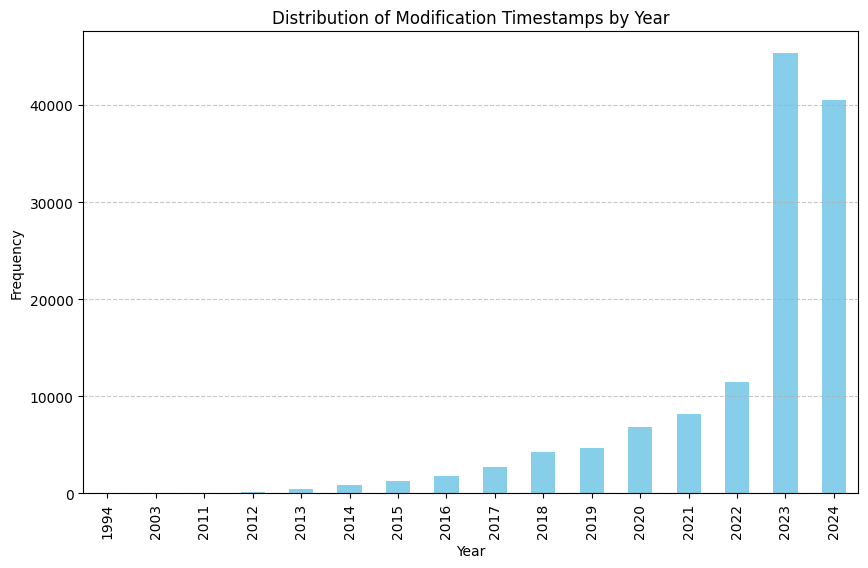

In [ ]:
import datetime

import matplotlib.pyplot as plt

# Convert Unix timestamps to datetime for better readability
df['mod_time'] = pd.to_datetime(df['mod_time_unix'], unit='s')

# Plot the distribution of timestamps
plt.figure(figsize=(10, 6))
df['mod_time'].dt.year.value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribution of Modification Timestamps by Year')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# adding LLM generated High signal content

In [ ]:
import pandas as pd

finance_df = pd.read_csv(f"{DATASET_PATH}/LLM_generated/finance_chatGPT.csv")
hr_df = pd.read_csv(f"{DATASET_PATH}/LLM_generated/hr_chatGPT.csv")

master_df = pd.read_csv(f"{DATASET_PATH}/merged/master_dataset_unlabeled.csv")

combined_llm = pd.concat([finance_df, hr_df], ignore_index=True)
combined_llm.drop(columns=["label_hr", "label_finance","label_it","label_general"], inplace=True)

master_with_llm = pd.concat([master_df, combined_llm], ignore_index=True)
master_with_llm.to_csv(f"{DATASET_PATH}/merged/master_dataset_with_llm_data.csv", index=False)

# generating high signal dataset

In [ ]:
import pandas as pd
import numpy as np

# --- CONFIGURATION ---
INPUT_CSV = f"{DATASET_PATH}/merged/master_dataset_with_llm_data.csv"
OUTPUT_CSV = f"{DATASET_PATH}/merged/high_signal_training_set.csv"

# Recency Cutoff: Jan 1, 2023
# Files older than this are "Stale" (Label 0), regardless of filename.
CUTOFF_UNIX = 1672531200 

def extract_pure_signal(input_path, output_path):
    print(f"💎 Loading {input_path} for High-Signal Extraction...")
    df = pd.read_csv(input_path)
    
    # Pre-calc strings
    df['name_lower'] = df['filename'].str.lower().fillna('')
    df['path_lower'] = df['path'].str.lower().fillna('')
    df['ext_lower'] = df['extension'].str.lower().fillna('')
    
    # --- 1. DEFINE PATTERNS (Filenames First) ---
    # We strictly require the filename to match, OR a very specific path+extension combo.
    
    # FINANCE
    # Must have explicit filename match OR be in a Payroll folder with a spreadsheet
    fin_names = ["budget", "invoice", "ledger", "tax", "forecast", "pnl", "balance", "payroll", "bank_stmt"]
    fin_exts = [".xlsx", ".xls", ".csv", ".pdf"]
    
    mask_fin = (df['name_lower'].str.contains('|'.join(fin_names))) | \
               (df['path_lower'].str.contains("payroll") & df['ext_lower'].isin(fin_exts))

    # HR
    # Must have explicit filename match OR be in a Personnel folder with a doc
    hr_names = ["resume", "cv_", "offer_letter", "bonus", "salary", "termination", "employee", "hiring", "candidate"]
    hr_exts = [".docx", ".doc", ".pdf"]
    
    mask_hr = (df['name_lower'].str.contains('|'.join(hr_names))) | \
              (df['path_lower'].str.contains("personnel|recruiting") & df['ext_lower'].isin(hr_exts))

    # IT (Infrastructure & Keys)
    # 1. Keys/Secrets (Always valid if recent)
    it_keys = [".pem", ".key", ".kdbx", ".ovpn", ".private", ".p12"]
    # 2. Critical Infrastructure Configs (Filename matches)
    it_configs = ["config", "id_rsa", "shadow", "passwd", "master", "prod", "database"]
    
    mask_it = (df['ext_lower'].isin(it_keys)) | \
              (df['name_lower'].str.contains('|'.join(it_configs)))

    # --- 2. APPLY RECENCY LOGIC (The "Time" Feature) ---
    is_recent = df['mod_time_unix'] >= CUTOFF_UNIX
    
    # --- 3. CREATE THE DATASETS ---
    
    # A. The "True Signal" (Matches Pattern + Recent) --> Label 1
    # We maintain the source type check to ensure we aren't pulling m57 noise by accident
    signal_mask = (mask_fin | mask_hr | mask_it) & is_recent & (df['source_type'] != 'system_noise')
    
    df_signal = df[signal_mask].copy()
    
    # Assign specific labels
    df_signal['label_finance'] = (mask_fin & is_recent & ~mask_hr & ~mask_it).astype(int)
    df_signal['label_hr'] = (mask_hr & is_recent & ~mask_fin & ~mask_it).astype(int)
    df_signal['label_it'] = (mask_it & is_recent).astype(int) # Priority to IT if overlap
    df_signal['label_general'] = 1

    # B. The "Stale" Class (Matches Pattern + OLD) --> Label 0
    # This is critical for your requirement.
    stale_mask = (mask_fin | mask_hr | mask_it) & ~is_recent
    
    df_stale = df[stale_mask].copy()
    # ALL labels are 0
    for col in ['label_finance', 'label_hr', 'label_it', 'label_general']:
        df_stale[col] = 0
        
    # --- 4. MERGE & EXPORT ---
    # We only keep these two groups. No random noise.
    df_final = pd.concat([df_signal, df_stale])
    
    # Shuffle
    df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Cleanup
    df_final.drop(columns=['name_lower', 'path_lower', 'ext_lower'], inplace=True)
    
    df_final.to_csv(output_path, index=False)
    
    print(f"✅ Extracted Condensed Dataset: {output_path}")
    print(f"   Total Rows: {len(df_final)}")
    print(f"   - True Signal (Recent, Label=1): {len(df_signal)}")
    print(f"   - Stale Negatives (Old, Label=0): {len(df_stale)}")
    print("\n   Label Distribution (in this condensed set):")
    print(df_final[['label_general', 'label_hr', 'label_it', 'label_finance']].mean())

# Execute
if __name__ == "__main__":
    extract_pure_signal(INPUT_CSV, OUTPUT_CSV)

💎 Loading ../datasets//merged/master_dataset_with_llm_data.csv for High-Signal Extraction...
✅ Extracted Condensed Dataset: ../datasets//merged/high_signal_training_set.csv
   Total Rows: 3598
   - True Signal (Recent, Label=1): 2802
   - Stale Negatives (Old, Label=0): 796

   Label Distribution (in this condensed set):
label_general    0.778766
label_hr         0.058366
label_it         0.622290
label_finance    0.096998
dtype: float64


In [ ]:
df = pd.read_csv(f"{DATASET_PATH}/merged/final_training_dataset_labeled.csv")
df.sample(5000).to_csv(f'{DATASET_PATH}/merged/df_sample_5k.csv', index=False)

## Adding IT secrets

In [ ]:
import random
import time

import pandas as pd
import numpy as np
import random
import time

def generate_high_value_IT_files(df_master, n_secrets=600):
    print(f"🌱 Grafting {n_secrets} diverse secrets onto existing GitHub paths...")
    
    # 1. Harvest Real Dev Paths
    git_paths = df_master[df_master['source_type'] == 'github_real']['path'].unique()
    
    secrets_data = []
    
    # --- LIST A: REPO ROOTS (Configs, Envs, Connection Strings) ---
    # These typically exist at the top level of a project or in a /config folder
    repo_secrets = [
        # Environment Variables
        ".env", ".env.production", ".env.local", ".env.test", ".env.example",
        
        # JSON Configs
        "config.json", "database.json", "settings.json", "secrets.json", 
        "credentials.json", "auth.json", "firebase.json", "client_secret.json",
        
        # YAML/XML Configs
        "config.yml", "database.yml", "application.yml", "kubeconfig.yaml",
        "web.config", "app.config", "nuget.config", "hibernate.cfg.xml",
        
        # Language Specific
        "settings.py", "local_settings.py", "config.py", "secrets.py", # Python
        "config.php", "wp-config.php", "database.php", # PHP
        "config.js", "secrets.js", "ormconfig.js", # Node/JS
    ]
    
    for _ in range(int(n_secrets * 0.5)):
        base_path = random.choice(git_paths)
        filename = random.choice(repo_secrets)
        
        # Heuristic: Find the "root" of the repo to place these files realistically
        if "\\" in base_path:
            parts = base_path.split("\\")
            # Try to place it at C:\Users\Dev\RepoName\ or C:\Users\Dev\RepoName\config
            if len(parts) > 4:
                # 80% chance to be at root, 20% to be in a config subfolder
                if random.random() > 0.2:
                    root_path = "\\".join(parts[:5]) 
                else:
                    root_path = "\\".join(parts[:5]) + "\\config"
            else:
                root_path = base_path
        else:
            root_path = base_path
            
        ext = "." + filename.split(".")[-1]
        secrets_data.append([filename, root_path, ext, random.randint(200, 4000), "secret_injection"])

    # --- LIST B: ACCIDENTAL COMMITS (Keys, Certs, Dumps, Wallets) ---
    # These can be scattered anywhere (backup folders, misc, root, src)
    key_secrets = [
        # SSH & Private Keys
        "id_rsa", "id_dsa", "id_ed25519", "id_ecdsa", "identity",
        "server.key", "private.key", "privkey.pem", "cert.pem", "key.pem",
        "host_key", "client.key", "auth_key",
        
        # Certificates & Keystores
        "keystore.jks", "certificate.p12", "cert.pfx", "client.ovpn",
        
        # Cloud & Service Credentials
        "access_keys.csv", "aws_credentials", "gcloud_auth.json", "azure_profile.json",
        
        # Database Dumps (High Value!)
        "backup.sql", "dump.sql", "users.sql", "production_db.sql", 
        "data.sqlite", "db.sqlite3", "production.sqlite", "accounts.dump",
        
        # Crypto
        "wallet.dat", "default_wallet", "keystore.json"
    ]
    
    for _ in range(int(n_secrets * 0.5)):
        base_path = random.choice(git_paths)
        filename = random.choice(key_secrets)
        
        # Add a "backup" or "misc" folder nuance occasionally
        if random.random() < 0.3:
            base_path += "\\" + random.choice(["backup", "bak", "dump", "old", "misc"])
            
        ext = "." + filename.split(".")[-1] if "." in filename else ""
        secrets_data.append([filename, base_path, ext, random.randint(1000, 150000), "secret_injection"])
        
    df_secrets = pd.DataFrame(secrets_data, columns=['filename', 'path', 'extension', 'size_bytes', 'source_type'])
    
    # Add timestamps (Recent) and Users (dev_injector)
    current = int(time.time())
    df_secrets['mod_time_unix'] = [current - random.randint(0, 365*24*3600) for _ in range(len(df_secrets))]
    df_secrets['source_user'] = "dev_injector" 
    
    return df_secrets

df = generate_high_value_IT_files(pd.read_csv(f"{DATASET_PATH}/merged/master_dataset_unlabeled.csv"), n_secrets=600)
df.to_csv(f"{DATASET_PATH}/github_code/high_value_it_secrets.csv", index=False)



🌱 Grafting 600 diverse secrets onto existing GitHub paths...


In [ ]:
import pandas as pd
import numpy as np
import random

# Load the secrets
df = pd.read_csv(f"{DATASET_PATH}/github_code/high_value_it_secrets.csv")

# 1. FIX DATES (Critical)
# Anchor to Jan 1, 2025
JAN_1_2025 = 1735689600
# Generate dates in the last 18 months
df['mod_time_unix'] = JAN_1_2025 - np.random.randint(0, 18 * 30 * 24 * 3600, size=len(df))

# 2. FIX PATHS (Cosmetic)
# Fix paths that are too shallow, e.g. "\\wsl$\Debian\home" -> "\\wsl$\Debian\home\deploy\project_x"
def improve_path(path):
    if path.endswith('home') or path.endswith('Users'):
        # Append a user and a repo
        user = random.choice(['dev', 'admin', 'deploy', 'runner'])
        repo = random.choice(['backend', 'api', 'core', 'auth-service'])
        if 'wsl' in path:
            return f"{path}\\{user}\\{repo}"
        else:
            return f"{path}\\{user}\\source\\repos\\{repo}"
    return path

df['path'] = df['path'].apply(improve_path)

# 3. SAVE FIXED
df.to_csv(f"{DATASET_PATH}/github_code/high_value_it_secrets_fixed.csv", index=False)
print("✅ Fixed timestamps and paths.")
print(df[['filename', 'path', 'mod_time_unix']].head())

✅ Fixed timestamps and paths.
     filename                                        path  mod_time_unix
0   config.py              C:\Users\kwatkins\source\repos     1697693856
1   auth.json              C:\Users\megan79\AppData\Local     1708657745
2  secrets.py  C:\Users\tiffany81\Dev\akosszasz.github.io     1707404754
3  config.yml        C:\Users\cloud_user\Dev\ESSArch_Core     1710518495
4  secrets.js         C:\Work\Projects\polar_express\spec     1729142285


## Merging IT secrets into master dataset

In [ ]:
master_df = pd.read_csv(f"{DATASET_PATH}/merged/master_dataset_with_llm_data.csv")
secrets_df = pd.read_csv(f"{DATASET_PATH}/github_code/high_value_it_secrets_fixed.csv")
combined_df = pd.concat([master_df, secrets_df], ignore_index=True)
combined_df.to_csv(f"{DATASET_PATH}/merged/master_with_secrets.csv", index=False)

## Random long file name noise

In [ ]:
import pandas as pd
import random
import string
import os
import time
from faker import Faker

def generate_realistic_long_noise(existing_df, n_samples=2500):
    fake = Faker()
    
    # 1. Setup Vocabulary
    # We mix "Good" extensions here purposely. 
    # We want the model to learn: "Even if it's a PDF, if the name is 150 chars long -> NOISE".
    mixed_extensions = [
        ".pdf", ".docx", ".xlsx", ".tmp", ".dat", ".log", 
        ".txt", ".jpg", ".png", ".cache", ".json"
    ]
    
    # Common "Garbage" Path Roots (mimic downloads/temp)
    garbage_roots = [
        r"C:\Users\User\AppData\Local\Temp",
        r"C:\Users\User\Downloads",
        r"C:\Windows\System32\DriverStore\FileRepository",
        r"C:\Users\User\AppData\Roaming\Microsoft\Windows\Recent"
    ]
    
    # 2. Harvest "Real" Paths from your dataset (if available)
    # This makes the noise blend in with the actual folders you have
    if 'path' in existing_df.columns and not existing_df.empty:
        # Sample 50 real paths and take their directories
        real_dirs = existing_df['path'].sample(n=min(len(existing_df), 50)).apply(os.path.dirname).tolist()
        garbage_roots.extend(real_dirs)

    noise_data = []
    
    print(f"Generating {n_samples} realistic long-name noise samples...")
    
    for _ in range(n_samples):
        # --- A. Generate the Base Name (Realistic) ---
        if random.random() < 0.6:
            # mimic a document name: "Financial_Report", "marketing_v2"
            base_name = f"{fake.word()}_{fake.word()}" 
        else:
            # mimic a system file: "ab49f2", "rt_driver"
            base_name = "".join(random.choices(string.ascii_lowercase + string.digits, k=8))

        # --- B. The "Longification" (mimic hashes/tokens) ---
        # Real noise usually has a long random string APPENDED or PREPENDED
        
        # Length: 60 to 180 chars (High variance)
        junk_len = random.randint(60, 180) 
        junk_str = "".join(random.choices(string.ascii_letters + string.digits + "-_", k=junk_len))
        
        # Strategy 1: Browser Download Style (Name + Hash)
        # e.g., "Invoice_2024_ACFrOgBMyWidcZQTdKT7lTrGV6MS9p4YVoVO.pdf"
        if random.random() < 0.5:
            long_filename = f"{base_name}_{junk_str}"
            
        # Strategy 2: Temp File Style (Hash + Name)
        # e.g., "tmp_ACFrOgBMyWidcZQTdKT7lTrGV6MS9p4YVoVO_setup.log"
        else:
            long_filename = f"{junk_str}_{base_name}"
            
        # Size Distribution: Mostly small files, some medium
        if random.random() < 0.9:
            fake_size = random.randint(0, 50 * 1024) # 0 to 50KB
        else:
            fake_size = random.randint(50 * 1024, 500 * 1024) # 50KB to 500KB

        # --- C. Final Assembly ---
        ext = random.choice(mixed_extensions)
        final_name = long_filename + ext
                
        noise_data.append({
            "filename": final_name,
            "path": random.choice(garbage_roots),
            "extension": ext,
            "size_bytes": fake_size,
            "mod_time_unix": time.time() - random.randint(0, 31536000), # Last year
            "source_user": "synthetic_noise",
            "source_type": "long_name_injector",
        })

    return pd.DataFrame(noise_data)

df = pd.read_csv(f"{DATASET_PATH}/merged/master_dataset_unlabeled.csv")

# --- EXECUTE INJECTION ---
df_long_noise = generate_realistic_long_noise(df)

df_long_noise.to_csv(f"{DATASET_PATH}/noise/long_name_noise.csv", index=False)

Generating 2500 realistic long-name noise samples...


In [ ]:
df_long_noise = pd.read_csv(f"{DATASET_PATH}/noise/long_name_noise.csv")
df_master = pd.read_csv(f"{DATASET_PATH}/merged/master_with_secrets.csv")
df_combined = pd.concat([df_master, df_long_noise], ignore_index=True)
df_combined.to_csv(f"{DATASET_PATH}/merged/master_with_secrets_and_longnoise.csv", index=False)

# dependency noise 

In [30]:
import pandas as pd
import random
import string
import os
import time
import pandas as pd
import random
import os
import time

def generate_dependency_noise(github_csv_path, output_csv_path, n_samples=5000):
    # Structure: Root -> List of possible mid-folders -> List of possible leaf-folders
    TOXIC_STRUCTURES = {
        "node_modules": {
            "mid": ["@babel", "lodash", "webpack", "react-dom", "typescript", "eslint", "ajv"],
            "leaf": ["dist", "lib", "src/main", "bin", "cjs/production", "esm/helpers"]
        },
        ".venv": {
            "mid": ["lib/python3.10/site-packages", "lib/python3.9/site-packages", "Scripts", "Include"],
            "leaf": ["pip", "setuptools", "pkg_resources/_vendor", "markupsafe", "jinja2"]
        },
        "target": {
            "mid": ["classes", "maven-status", "generated-sources", "test-classes"],
            "leaf": ["com/app/internal", "org/apache/util", "annotations/temp", "compile/default"]
        },
        ".git": {
            "mid": ["objects", "refs/heads", "hooks", "info", "logs/refs"],
            "leaf": ["pack", "remotes/origin", "main", "tags"]
        },
        ".vscode": {
            "mid": ["extensions/ms-python.python", "pylance/dist", "cpptools/bin/linux-x64", "settings"],
            "leaf": ["out/client", "bin/debug_adapter", "server/pylance/resources"]
        },
        "build": {
            "mid": ["intermediates/asm_instrumented_classes", "outputs/apk/debug", "tmp/kotlin-classes", "generated/source/buildConfig"],
            "leaf": ["debug/internal", "release/stripped", "res/merged", "compile_commands"]
        },
        "obj": {
            "mid": ["Debug/net6.0", "Release/x64", "temp", "project.assets"],
            "leaf": ["ref", "incremental/build", "host/bin", "native"]
        },
        "__pycache__": {
            "mid": ["", "v3.10", "v3.11", "v3.9"], 
            "leaf": [""] # Pycache is usually shallow
        },
        "docker": {
        "mid": ["build/context", "images/base", "compose/services", "layers"],
        "leaf": ["cache", "temp_config", "metadata"]
        },
        "cmake": {
            "mid": ["CMakeFiles", "build/generated", "external/project"],
            "leaf": ["bin", "include", "lib/static"]
        },
        "k8s": {
            "mid": ["manifests/base", "overlays/production", "charts/templates"],
            "leaf": ["crds", "hooks", "generated"]
    }
    }

    # Filename strategy: 40% High-Value (Hard Negatives), 60% Generic Junk
    hard_negatives = ["config.json", "settings.py", "credentials.xml", ".env", "auth.js", "private.key", "id_rsa",
        "Dockerfile", "docker-compose.yml", "CMakeLists.txt", ".gitignore", "package.json", "requirements.txt"]
    
    junk_extensions = [
        ".class", ".o", ".obj", ".pyc", ".pyd", ".pyi", ".dll", ".so",
        ".map", ".log", ".cache", ".tmp", ".node", ".lcl", ".cat",
        ".inf", ".pdb", ".ilk", ".exp", ".lib", ".tlog", ".lastbuildstate",
        ".mo", ".gmo", ".a", ".la", ".lo", ".slo", ".target", ".lst",
        ".metadata", ".bin", ".out", ".exe", ".timestamp", ".suo", ".user"
    ]

    github_df = pd.read_csv(github_csv_path)
    real_paths = github_df['path'].dropna().unique().tolist()
    
    noise_data = []
    print(f"☣️ Generating {n_samples} Targeted Toxic Samples...")

    for _ in range(n_samples):
        base_path = random.choice(real_paths)
        sep = "\\" if "\\" in base_path else "/"
        
        # Pick a structure
        root = random.choice(list(TOXIC_STRUCTURES.keys()))
        mid = random.choice(TOXIC_STRUCTURES[root]["mid"])
        leaf = random.choice(TOXIC_STRUCTURES[root]["leaf"])
        
        # Build path with realistic depth
        full_path = f"{base_path}{sep}{root}{sep}{mid}{sep}{leaf}".replace("/", sep).replace("\\", sep)

        # Decide on filename
        if random.random() < 0.3: # 30% Hard Negative
            final_name = random.choice(hard_negatives)
        else: # 70% Random Artifact Name
            prefix = "".join(random.choices("abcdef0123456789", k=8))
            final_name = f"{prefix}{random.choice(junk_extensions)}"

        # Realistic Size: Log-Normal Distribution
        # mean=10, sigma=2 results in most files being ~20KB, with occasional 50MB outliers
        size_bytes = int(np.random.lognormal(mean=10.5, sigma=1.8))
        size_bytes = max(10, min(size_bytes, 100 * 1024 * 1024)) # Cap at 100MB

        noise_data.append({
            "filename": final_name,
            "path": full_path,
            "extension": os.path.splitext(final_name)[1],
            "size_bytes": size_bytes,
            "mod_time_unix": time.time() - random.randint(0, 3 * 31536000), # 0-3 years old
            "source_user": "structural_toxic_gen",
            "source_type": "dependency_noise",
        })

    df = pd.DataFrame(noise_data)
    df.to_csv(output_csv_path, index=False)
    print(f"✅ Success: {len(df)} structural samples saved.")

# --- RUN SCRIPT ---
INPUT_FILE = f'{DATASET_PATH}/github_code/github_with_paths.csv'
OUTPUT_FILE = f'{DATASET_PATH}/noise/dependency_build_noise.csv'

generate_dependency_noise(INPUT_FILE, OUTPUT_FILE, n_samples= 10000)

☣️ Generating 10000 Targeted Toxic Samples...
✅ Success: 10000 structural samples saved.


In [31]:
df_dependency_noise = pd.read_csv(f"{DATASET_PATH}/noise/dependency_build_noise.csv")
df_master = pd.read_csv(f"{DATASET_PATH}/merged/master_with_secrets_and_longnoise.csv")
df_combined = pd.concat([df_master, df_dependency_noise], ignore_index=True)
df_combined.to_csv(f"{DATASET_PATH}/merged/master_with_secrets_long_noise_dependency_noise.csv", index=False)

## Extraction of high signal files and labeling

In [ ]:
import pandas as pd
import numpy as np


def extract_high_fidelity_signal(input_path, output_path):
    print(f"💎 Loading {input_path} for High-Fidelity Curation...")
    df = pd.read_csv(input_path)

    # Pre-process
    df["name_lower"] = df["filename"].str.lower().fillna("")
    df["path_lower"] = df["path"].str.lower().fillna("")
    df["ext_lower"] = df["extension"].str.lower().fillna("")

    # --- THE CONSTRAINTS ---
    # Only these extensions are allowed to be labeled as documents
    document_exts = [".pdf", ".docx", ".doc", ".xlsx", ".xls", ".csv", ".rtf", ".pptx", ".odt", ".ods"]

    # --- 1. FINANCE SIGNAL (STRICT) ---
    fin_names = ["budget", "invoice", "ledger", "forecast", "pnl", "payroll", "bank_stmt"]
    
    # Rule: Name must contain keyword AND must be a document extension
    mask_fin_name = (df["name_lower"].str.contains("|".join(fin_names))) & (df["ext_lower"].isin(document_exts))
    
    # Rule: Path contains 'payroll' AND must be a document extension
    mask_fin_path = (df["path_lower"].str.contains("payroll")) & (df["ext_lower"].isin(document_exts))
    
    mask_fin = mask_fin_name | mask_fin_path

    # --- 2. HR SIGNAL (STRICT) ---
    hr_names = ["resume", "cv_", "offer_letter", "bonus", "salary", "termination", "employee", "hiring", "candidate"]
    
    # Rule: Name must contain keyword AND must be a document extension
    mask_hr_name = (df["name_lower"].str.contains("|".join(hr_names))) & (df["ext_lower"].isin(document_exts))
    
    # Rule: Path contains personnel/recruiting AND must be a document extension
    mask_hr_path = (df["path_lower"].str.contains("personnel|recruiting")) & (df["ext_lower"].isin(document_exts))
    
    mask_hr = mask_hr_name | mask_hr_path

    # --- 3. IT SIGNAL DETECTION (Keep as is) ---
    mask_injected = df["source_type"] == "secret_injection"
    it_keys = [".pem", ".key", ".kdbx", ".p12", ".ovpn", ".private", ".wallet", ".asc", ".gpg"]
    mask_it_keys = df["ext_lower"].isin(it_keys)
    it_secrets = ["id_rsa", "id_ed25519", "shadow", "passwd", "master.password", ".env", "secrets.yml", "credentials.json", "backup.sql", "dump.sql"]
    mask_it_names = df["name_lower"].isin(it_secrets) | df["name_lower"].str.startswith(".env")
    
    it_context_files = ["web.config", "appsettings.json", "settings.py", "config.json", "database.yml"]
    sensitive_paths = ["prod", "secret", "conf", "wwwroot", "deploy", "auth"]
    mask_it_context = (df["name_lower"].isin(it_context_files)) & (df["path_lower"].str.contains("|".join(sensitive_paths)))
    
    mask_it = mask_injected | mask_it_keys | mask_it_names | mask_it_context

    # --- 4. CONSTRUCT DATASET ---
    is_not_noise = ~df["source_type"].isin(["system_noise", "long_name_injector", "dependency_noise"])
    
    # TOXIC FOLDER FILTER
    toxic_folders = ["node_modules", "site-packages", ".git", ".venv", "__pycache__", "build", "dist", "target"]
    mask_not_toxic = ~df["path_lower"].str.contains('|'.join(toxic_folders), na=False)

    # Positive Mask: High-value pattern AND recent AND not in a toxic folder
    pos_mask = (mask_fin | mask_hr | mask_it) & is_not_noise & mask_not_toxic

    df_pos = df[pos_mask].copy()
    df_pos["label_finance"] = mask_fin.astype(int)
    df_pos.loc[mask_it, "label_finance"] = 0 # IT wins
    df_pos["label_hr"] = mask_hr.astype(int)
    df_pos["label_it"] = mask_it.astype(int)
    df_pos["label_general"] = 1

    df_final = df_pos.copy()
    df_final.drop(columns=["name_lower", "path_lower", "ext_lower"], inplace=True)
    df_final.to_csv(output_path, index=False)

    print(f"✅ Extracted High-Fidelity Dataset: {output_path}")
    print(f"   - Positive Samples (Recent, Label=1): {len(df_pos)}")
    print("\n   Label Distribution (in this high-fidelity set):")
    print(f"     - IT Rows: {df_final['label_it'].sum()}")
    print(f"     - Finance Rows: {df_final['label_finance'].sum()}")
    print(f"     - HR Rows: {df_final['label_hr'].sum()}")
    print(df_final[["label_general", "label_hr", "label_it", "label_finance"]].mean())

    print(f"✅ Success! Total Rows: {len(df_final)}")

INPUT_CSV = f"{DATASET_PATH}/merged/master_with_secrets_long_noise_dependency_noise.csv"
OUTPUT_CSV = f"{DATASET_PATH}/labeled_data/high_signal_set_with_secrets_long_noise_dependecy_noise.csv"

extract_high_fidelity_signal(INPUT_CSV, OUTPUT_CSV)

💎 Loading ../datasets//merged/master_with_secrets_long_noise_dependency_noise.csv for High-Fidelity Curation...
✅ Extracted High-Fidelity Dataset: ../datasets//labeled_data/high_signal_set_with_secrets_long_noise_dependecy_noise.csv
   - Positive Samples (Recent, Label=1): 1221

   Label Distribution (in this high-fidelity set):
     - IT Rows: 481
     - Finance Rows: 268
     - HR Rows: 477
label_general    1.000000
label_hr         0.390663
label_it         0.393939
label_finance    0.219492
dtype: float64
✅ Success! Total Rows: 1221


# Assembly of training dataset

In [57]:
import pandas as pd
import numpy as np

# Fixed Epoch: 01/01/2026
REF_DATE = 1767225600 
ONE_YEAR = 365 * 86400

def assemble_balanced_dataset():
    print("⚖️  Assembling Final Balanced Dataset...")
    
    # 1. Load the High Signal Set (The Foundation)
    df_signal = pd.read_csv(SIGNAL_CSV)
    n_signal_rows = len(df_signal)
    print(f"   - Loaded Signal/Stale Set: {n_signal_rows} rows")
    
    # 2. Load Master to harvest Noise
    df_master = pd.read_csv(MASTER_CSV)
    
    # Pre-process master for filtering
    df_master['name_lower'] = df_master['filename'].str.lower().fillna('')
    df_master['ext_lower'] = df_master['extension'].str.lower().fillna('')

    # --- 3. DEFINE EXCLUSION MASKS ---
    # We must ensure we don't accidentally pick a "Hidden Gem" as noise.
    # We re-use the strict logic to exclude anything that MIGHT be signal.
    
    # IT Signal Pattern
    mask_injected = (df_master['source_type'] == 'secret_injection')
    it_keys = [".pem", ".key", ".kdbx", ".p12", ".ovpn", ".private", ".wallet"]
    it_secrets = ["id_rsa", "shadow", "passwd", ".env", "secrets.yml", "credentials.json"]
    mask_it = (df_master['ext_lower'].isin(it_keys)) | (df_master['name_lower'].isin(it_secrets)) | mask_injected
    
    # Finance/HR Signal Pattern
    fin_hr_terms = ["budget", "invoice", "payroll", "tax", "resume", "cv_", "salary", "hiring"]
    mask_biz = df_master['name_lower'].str.contains('|'.join(fin_hr_terms))
    
    # The "Do Not Touch" Mask (Any potential signal)
    mask_potential_signal = mask_it | mask_biz
    
    # --- 4. HARVEST PURE NOISE ---
    n_biz = n_signal_rows 
    n_dev = n_signal_rows 
    n_dependency = n_signal_rows
    n_long = n_signal_rows // 5
    n_system = n_signal_rows // 3
    
    # A. Business Noise (GovDocs that aren't Finance/HR)
    # e.g. "meeting_minutes.doc", "safety_regulations.pdf"
    pool_biz = df_master[
        (df_master['source_type'] == 'govdoc_real') & 
        ~mask_potential_signal
    ]
    df_biz_noise = pool_biz.sample(n=min(len(pool_biz), n_biz))
    
    # B. Dev Noise (GitHub that isn't Keys/Secrets)
    # e.g. "style.css", "readme.md", "index.html", "utils.js"
    pool_dev = df_master[
        (df_master['source_type'] == 'github_real') & 
        ~mask_potential_signal
    ]
    df_dev_noise = pool_dev.sample(n=min(len(pool_dev), n_dev))
    
    # C. System Noise (M57/Windows)
    # e.g. "driver.sys", "icon.png", "help.chm"
    pool_sys = df_master[
        (df_master['source_type'] == 'system_noise') & 
        ~mask_potential_signal
    ]
    df_sys_noise = pool_sys.sample(n=min(len(pool_sys), n_system))
    
    # D. Long Name Noise (The New Critical Category)
    # This specifically targets the "ACFrOgB..." type files
    pool_long_noise = df_master[
        (df_master['source_type'] == 'long_name_injector')
    ]
    df_long_noise = pool_long_noise.sample(n=min(len(pool_long_noise), n_long))

    # E. dependency noise:
    # e.g. "node_modules", "build/temp/file.o"
    pool_dependency_noise = df_master[
        (df_master['source_type'] == 'dependency_noise')
    ]
    df_dependency_noise = pool_dependency_noise.sample(n=min(len(pool_dependency_noise), n_dependency))

    # --- 5. LABEL & MERGE ---
    # All noise gets 0 across the board
    df_noise = pd.concat([df_biz_noise, df_dev_noise, df_sys_noise, df_long_noise, df_dependency_noise])
    for col in ['label_finance', 'label_hr', 'label_it', 'label_general']:
        df_noise[col] = 0
    

    # Drop temp columns
    df_noise.drop(columns=['name_lower', 'ext_lower'], inplace=True, errors='ignore')
    
    # Concatenate with the High Signal Set
    df_final = pd.concat([df_signal, df_noise])
    
   # --- 6. CAPTURE PRE-SHIFT STATS ---
    # We store the "Signal Potential" before we start turning rows stale
    pre_shift_it = df_final['label_it'].sum()
    pre_shift_fin = df_final['label_finance'].sum()
    pre_shift_hr = df_final['label_hr'].sum()
    
    # --- 7. QUADRANT MANIPULATION ---
    has_keywords = df_final['label_general'] == 1
    
    # Quadrant 1: Fresh Signal (Label 1)
    mask_q1 = has_keywords & (np.random.rand(len(df_final)) > 0.3) 
    df_final.loc[mask_q1, 'mod_time_unix'] = REF_DATE - np.random.randint(0, ONE_YEAR, size=mask_q1.sum())
    
    # Quadrant 2: Stale Signal (Label 0)
    # This is where the "Turned Stale" happens
    mask_q2 = has_keywords & ~mask_q1
    stale_signal_count = mask_q2.sum()
    
    # Capture focus-specific stale counts BEFORE overwriting them
    stale_fin_count = df_final.loc[mask_q2, 'label_finance'].sum()
    stale_hr_count = df_final.loc[mask_q2, 'label_hr'].sum()
    stale_it_count = df_final.loc[mask_q2, 'label_it'].sum()

    # Apply the "Kill Switch" to Labels
    df_final.loc[mask_q2, 'mod_time_unix'] = REF_DATE - np.random.randint(ONE_YEAR, 10*ONE_YEAR, size=mask_q2.sum())
    df_final.loc[mask_q2, ['label_general', 'label_finance', 'label_hr', 'label_it']] = 0
    
    # Quadrant 3 & 4: Junk (Remain 0)
    mask_junk = ~has_keywords
    mask_q3 = mask_junk & (np.random.rand(len(df_final)) > 0.2)
    df_final.loc[mask_q3, 'mod_time_unix'] = REF_DATE - np.random.randint(0, ONE_YEAR, size=mask_q3.sum())
    
    mask_q4 = mask_junk & ~mask_q3
    df_final.loc[mask_q4, 'mod_time_unix'] = REF_DATE - np.random.randint(ONE_YEAR, 10*ONE_YEAR, size=mask_q4.sum())
    
    # --- 8. FINAL SHUFFLE & EXPORT ---
    df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)
    df_final.to_csv(FINAL_CSV, index=False)
    
    print(f"\n📊 FINAL BREAKDOWN BY FOCUS (REF: {REF_DATE})")
    print("-" * 50)
    print(f"FOCUS    | TOTAL SIGNAL | REMAIN LBL 1 (FRESH) | TURNED LBL 0 (STALE)")
    print("-" * 50)
    print(f"GENERAL  | {has_keywords.sum():<12} | {mask_q1.sum():<20} | {mask_q2.sum():<18}")
    print(f"FINANCE  | {pre_shift_fin:<12} | {pre_shift_fin - stale_fin_count:<20} | {stale_fin_count:<18}")
    print(f"HR       | {pre_shift_hr:<12} | {pre_shift_hr - stale_hr_count:<20} | {stale_hr_count:<18}")
    print(f"IT       | {pre_shift_it:<12} | {pre_shift_it - stale_it_count:<20} | {stale_it_count:<18}")
    print("-" * 50)
    print(f"PURE NOISE ADDED: {len(df_noise)} (Recent: {mask_q3.sum()}, Ancient: {mask_q4.sum()})")
    print(f"noise breakdown -> Business: {len(df_biz_noise)}, Dev: {len(df_dev_noise)}, System: {len(df_sys_noise)}, Long Name: {len(df_long_noise)}, Dependency: {len(df_dependency_noise)}")
    
    # Final Distribution Check
    print("\n   Target Probabilities (Ideally ~30-50% for General):")
    print(df_final[['label_general', 'label_hr', 'label_it', 'label_finance']].mean())

# --- CONFIGURATION ---
# Inputs
SIGNAL_CSV = f"{DATASET_PATH}/labeled_data/high_signal_set_with_secrets_long_noise_dependecy_noise.csv"
MASTER_CSV = f"{DATASET_PATH}/merged/master_with_secrets_long_noise_dependency_noise.csv"
# Output
FINAL_CSV = f"{DATASET_PATH}/labeled_data/final_training_dataset_ready.csv"

assemble_balanced_dataset()

⚖️  Assembling Final Balanced Dataset...
   - Loaded Signal/Stale Set: 1221 rows

📊 FINAL BREAKDOWN BY FOCUS (REF: 1767225600)
--------------------------------------------------
FOCUS    | TOTAL SIGNAL | REMAIN LBL 1 (FRESH) | TURNED LBL 0 (STALE)
--------------------------------------------------
GENERAL  | 1221         | 868                  | 353               
FINANCE  | 268          | 180                  | 88                
HR       | 477          | 344                  | 133               
IT       | 481          | 348                  | 133               
--------------------------------------------------
PURE NOISE ADDED: 4314 (Recent: 3452, Ancient: 862)
noise breakdown -> Business: 1221, Dev: 1221, System: 407, Long Name: 244, Dependency: 1221

   Target Probabilities (Ideally ~30-50% for General):
label_general    0.156820
label_hr         0.062150
label_it         0.062873
label_finance    0.032520
dtype: float64


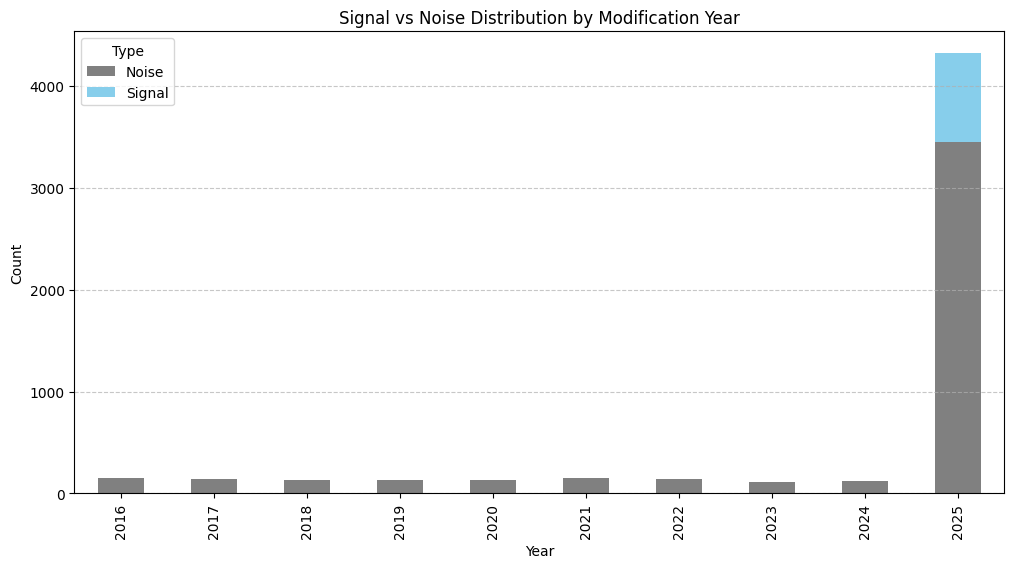

In [58]:
df = pd.read_csv(f"{DATASET_PATH}/labeled_data/final_training_dataset_ready.csv")

import matplotlib.pyplot as plt

# Add a column to classify rows as signal or noise
df['is_signal'] = (df['label_general'] == 1).astype(int)

# Convert modification time to year for grouping
df['mod_year'] = pd.to_datetime(df['mod_time_unix'], unit='s').dt.year

# Group by year and calculate counts for signal and noise
signal_noise_counts = df.groupby('mod_year')['is_signal'].value_counts().unstack(fill_value=0)
signal_noise_counts.columns = ['Noise', 'Signal']

# Plot the bar chart
signal_noise_counts.plot(kind='bar', stacked=True, figsize=(12, 6), color=['gray', 'skyblue'])
plt.title('Signal vs Noise Distribution by Modification Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()